# 01 · GRPO 拿不到梯度：组内 reward 方差为零

**对应 HANDOFF §6 P0**「验 backward + docking + **reward** 全链路」。

前两项通过。第三项**未通过**——但不是我最初以为的那样，
所以先把纠正写在最前面。


## 先纠正一次读错字段

我先前的结论是「reward 从来没有非零过」，依据是 `rollout/rewards`
一直在 `1e-8` 量级。**那个字段不是环境给的 reward。**

slime 在同一个字典里记三样含义完全不同的东西：

| 字段 | 是什么 |
|---|---|
| `rollout/raw_reward` | **环境返回的 reward**（这条线上就是 EHVI） |
| `rollout/rewards` | **GRPO 归一化后的 advantage**，即 `(r − mean) / std` |
| `rollout/zero_std/count_0.0` | 本步里有几个组的 reward 标准差为 0 |

读对字段之后，图景整个反过来：

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results")
def load(name): return json.loads((R / name).read_text())

aud = load("reward_audit.json")
print(f'{aud["n_runs"]} runs, {aud["n_steps_total"]} steps')
print(f'  env reward > 1e-6   : {aud["raw_above_1e6_total"]}/{aud["n_steps_total"]}'
      f' = {100*aud["raw_above_1e6_total"]/aud["n_steps_total"]:.1f}%')
print(f'  zero-variance groups: {aud["zero_std_total"]}')

43 runs, 771 steps
  env reward > 1e-6   : 663/771 = 86.0%
  zero-variance groups: 565


**环境 reward 一直是正常的**：87% 的步在 `1e-6` 以上，中位数落在 `1e-2`，
正是 EHVI 该有的量级。坏掉的是**方差**。

这个教训是「指标的名字不等于它的语义」：`rollout/rewards` 读起来就是 reward，
而真正的 reward 在同一个字典里叫 `raw_reward`。

## 图 1 — 环境 reward 正常，归一化后的 advantage 却是零

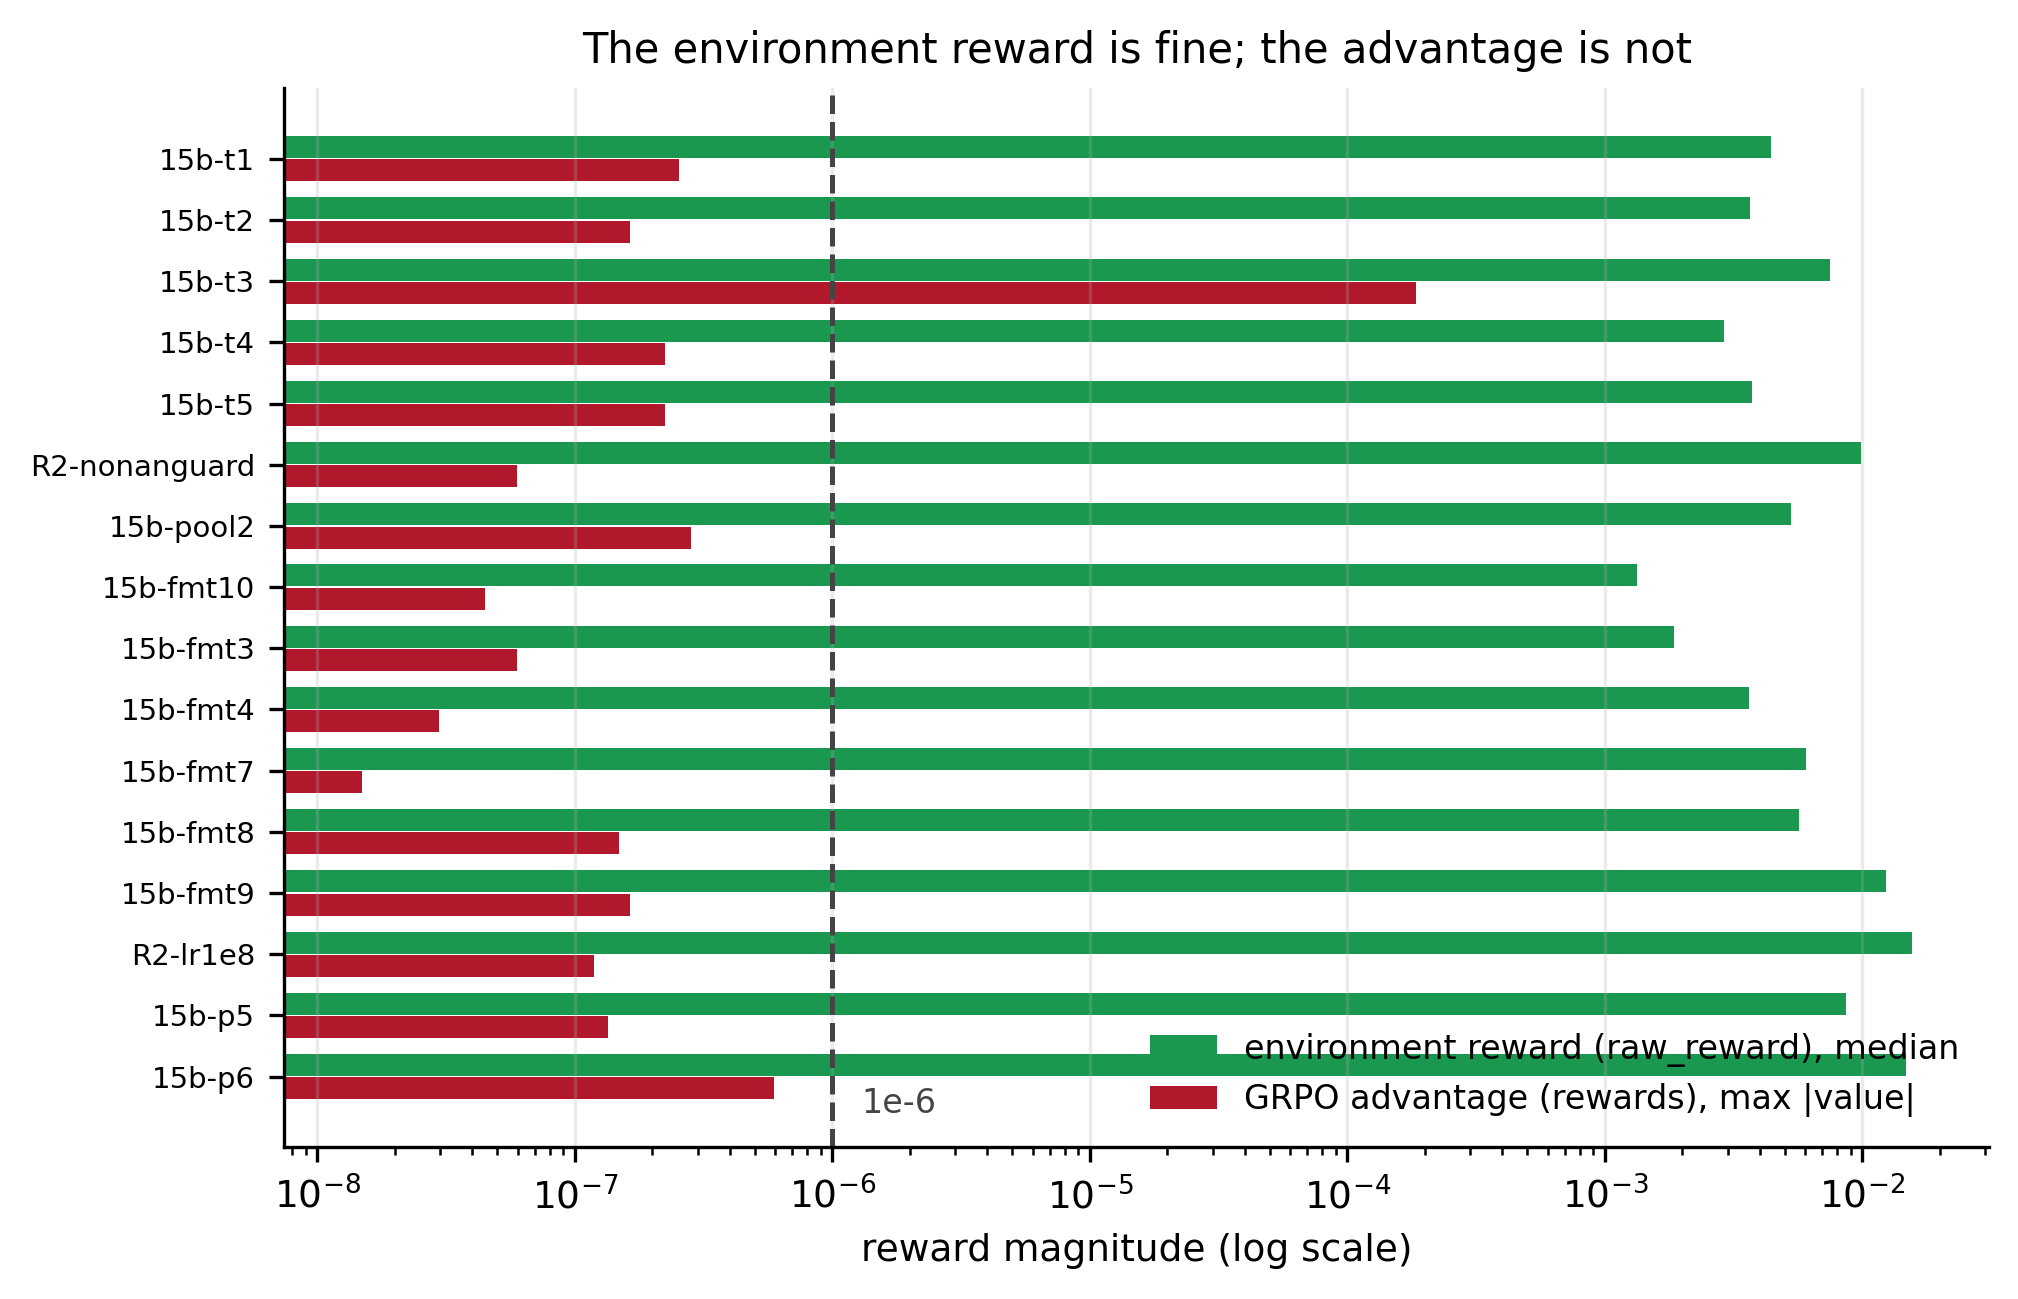

In [2]:
runs = [r for r in aud["runs"] if r["n_steps"] >= 5]
runs = sorted(runs, key=lambda r: -r["n_steps"])[:16]
fig, ax = plt.subplots(figsize=(6.8, 4.4))
y = np.arange(len(runs))
ax.barh(y - .19, [max(r["raw_median"], 1e-9) for r in runs], height=.36,
        color="#1a9850", label="environment reward (raw_reward), median")
ax.barh(y + .19, [max(r["adv_max_abs"], 1e-9) for r in runs], height=.36,
        color="#b2182b", label="GRPO advantage (rewards), max |value|")
ax.set_yticks(y); ax.set_yticklabels([r["run"][:22] for r in runs], fontsize=7)
ax.invert_yaxis(); ax.set_xscale("log")
ax.axvline(1e-6, ls="--", lw=1.2, color="#444444")
ax.text(1.3e-6, len(runs) - .4, "1e-6", fontsize=8, color="#444444")
ax.set_xlabel("reward magnitude (log scale)")
ax.set_title("The environment reward is fine; the advantage is not", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：绿色（环境 reward）几乎全在 `1e-6` 右侧、多数在 `1e-2` 附近；
红色（归一化后的 advantage）全部贴在左边。**同一批步，两个量差六个数量级。**

差在哪里：`advantage = (r − mean) / std`。当一个组里所有轨迹拿到**相同**的
reward 时，分子是 0、分母也是 0，slime 的 `+1e-6` 保护让结果有限但无意义。
**梯度来自组内的差异，不是 reward 的绝对值**——reward 再大也没用。

## 图 2 — 零方差有多频繁

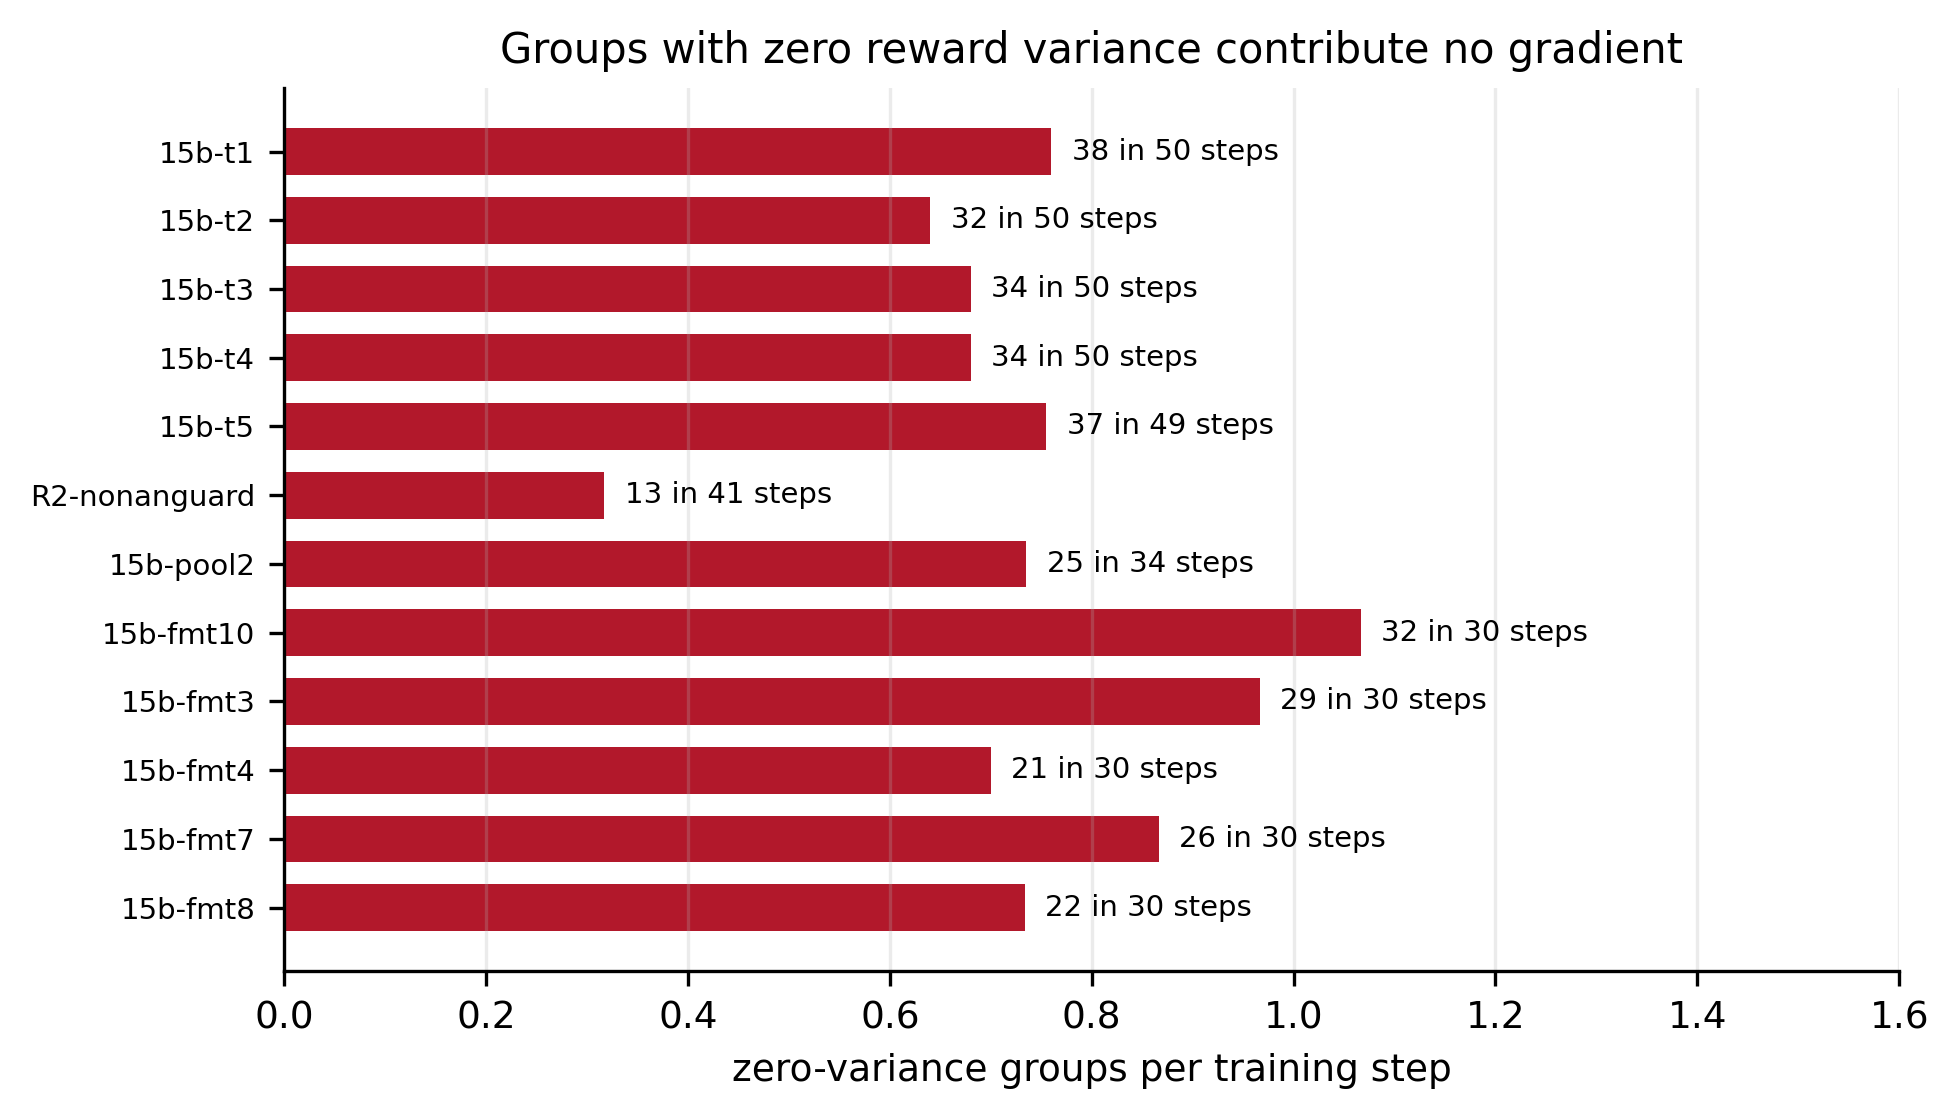

In [3]:
sub = [r for r in aud["runs"] if r["n_steps"] >= 10]
sub = sorted(sub, key=lambda r: -r["n_steps"])[:12]
fig, ax = plt.subplots(figsize=(6.6, 3.8))
y = np.arange(len(sub))
per_step = [r["zero_std_total"] / max(r["n_steps"], 1) for r in sub]
ax.barh(y, per_step, color="#b2182b", height=.68)
for i, (r, v) in enumerate(zip(sub, per_step)):
    ax.text(v + .02, i, f'{r["zero_std_total"]} in {r["n_steps"]} steps',
            va="center", fontsize=7)
ax.set_yticks(y); ax.set_yticklabels([r["run"][:22] for r in sub], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("zero-variance groups per training step")
ax.set_title("Groups with zero reward variance contribute no gradient", fontsize=10)
ax.set_xlim(0, max(per_step) * 1.5); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：几乎每一步都有零方差的组。这些组对参数更新的贡献是零。

## 零方差从哪来：解析失败让整组一起拿 0

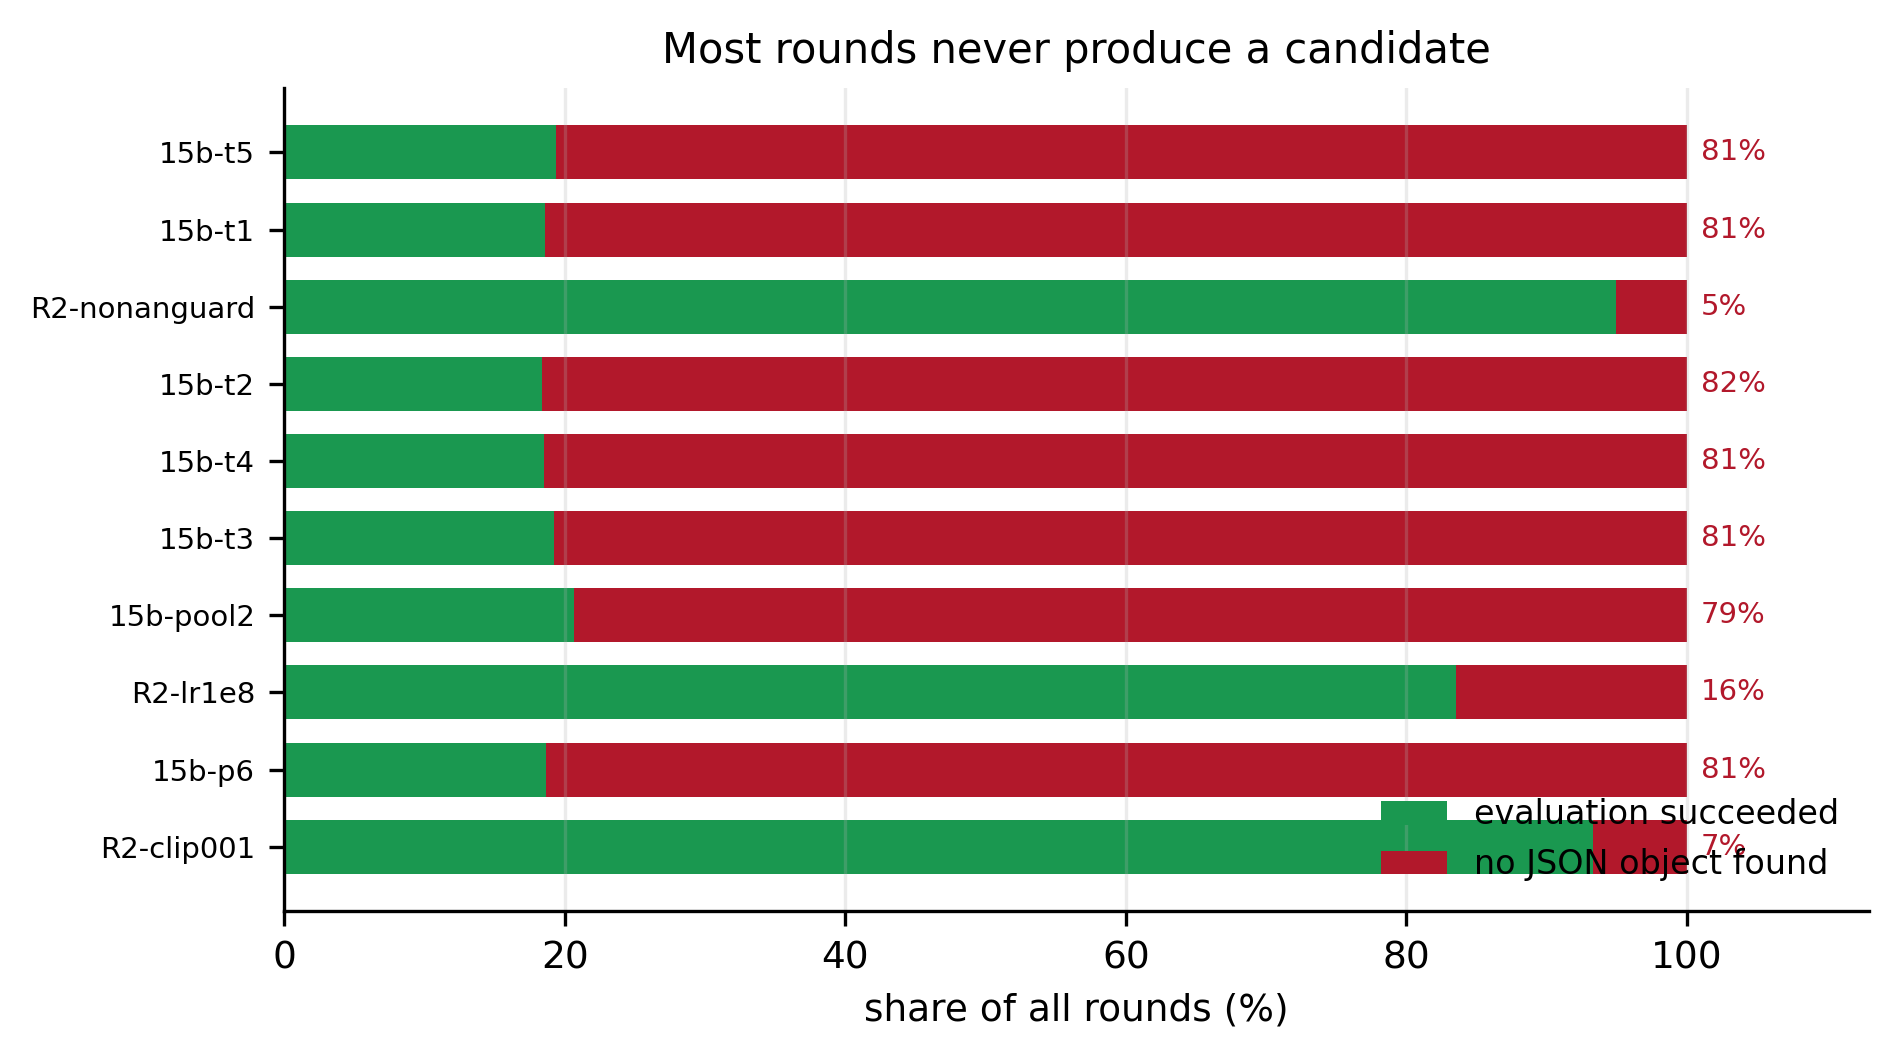

In [4]:
sub = [r for r in aud["runs"] if r["n_parse_fail"] + r["n_succeeded"] >= 20]
sub = sorted(sub, key=lambda r: -(r["n_parse_fail"] + r["n_succeeded"]))[:10]
fig, ax = plt.subplots(figsize=(6.4, 3.6))
y = np.arange(len(sub))
ok = np.array([r["n_succeeded"] for r in sub], float)
bad = np.array([r["n_parse_fail"] for r in sub], float)
tot = ok + bad
ax.barh(y, 100*ok/tot, color="#1a9850", height=.7, label="evaluation succeeded")
ax.barh(y, 100*bad/tot, left=100*ok/tot, color="#b2182b", height=.7,
        label="no JSON object found")
for i in range(len(sub)):
    ax.text(101, i, f"{100*bad[i]/tot[i]:.0f}%", va="center", fontsize=7, color="#b2182b")
ax.set_yticks(y); ax.set_yticklabels([r["run"][:22] for r in sub], fontsize=7)
ax.invert_yaxis(); ax.set_xlim(0, 113)
ax.set_xlabel("share of all rounds (%)")
ax.set_title("Most rounds never produce a candidate", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：旧代码下**八成以上的轮次解析失败**。这看起来像是零方差的
成因——失败的轮次没有候选、reward 记 0，一个组全失败就全 0。

**但下面图 4 的测量否掉了这条因果**：解析失败率修到 0.5% 之后，
零方差每步反而略升。所以这两件事是独立的，
解析失败只是一个同时存在的问题，不是零方差的来源。

## 解析为什么失败：环境观测破坏了 chat 格式

日志里 `Finish rollout` 带着模型的**实际输入**：

```
{"direct_smiles": [...]}<|im_end|><round 0>
Received 2 candidate proposal(s).
- mol-19efc8c41e45: SUCCEEDED metrics={"activity": 6.707, "vina": -5.005}
Best so far: 1 successful evaluation(s); no single best with multiple objectives.
Propose the next candidates.<|im_end|><round 1>
Your response could not be parsed as a proposal: no JSON object found
```

`rl/ldm_rl/bridge.py` 是 `response += step.observation`——
**观测直接接在 `<|im_end|>` 后面，没有 `<|im_start|>user` 包裹**。
对 Qwen 的 chat template 来说，`<|im_end|>` 之后必须是新的角色标记。

| | 结果 | 为什么 |
|---|---|---|
| **round 0** | 永远成功 | 那一轮的 prompt 走了 `_apply_chat_template` |
| **round 1 及以后** | 几乎全失败 | 模型输出里连 `{` 都没有 |


## 修复与判定标准

已改：`bridge.py` 的 `_observation_wrapper` 用 tokenizer 自己的 chat template
生成包裹（不硬编码任何模型的特殊 token），61 个单元测试仍全过。

**判定标准是在看到结果之前写下的**：

1. 解析失败率应从 ~81% 显著下降；
2. `zero_std/count_0.0` 每步的个数应下降；
3. `rollout/rewards`（advantage）应出现 `1e-6` 以上的取值。

并且预先写明：**只满足 1 而不满足 2、3**，说明解析不是零方差的主要来源，
要转去查 `n_samples_per_prompt` 与候选去重。

## 图 4 — 结果：解析失败被消除，而零方差**没有**跟着下降

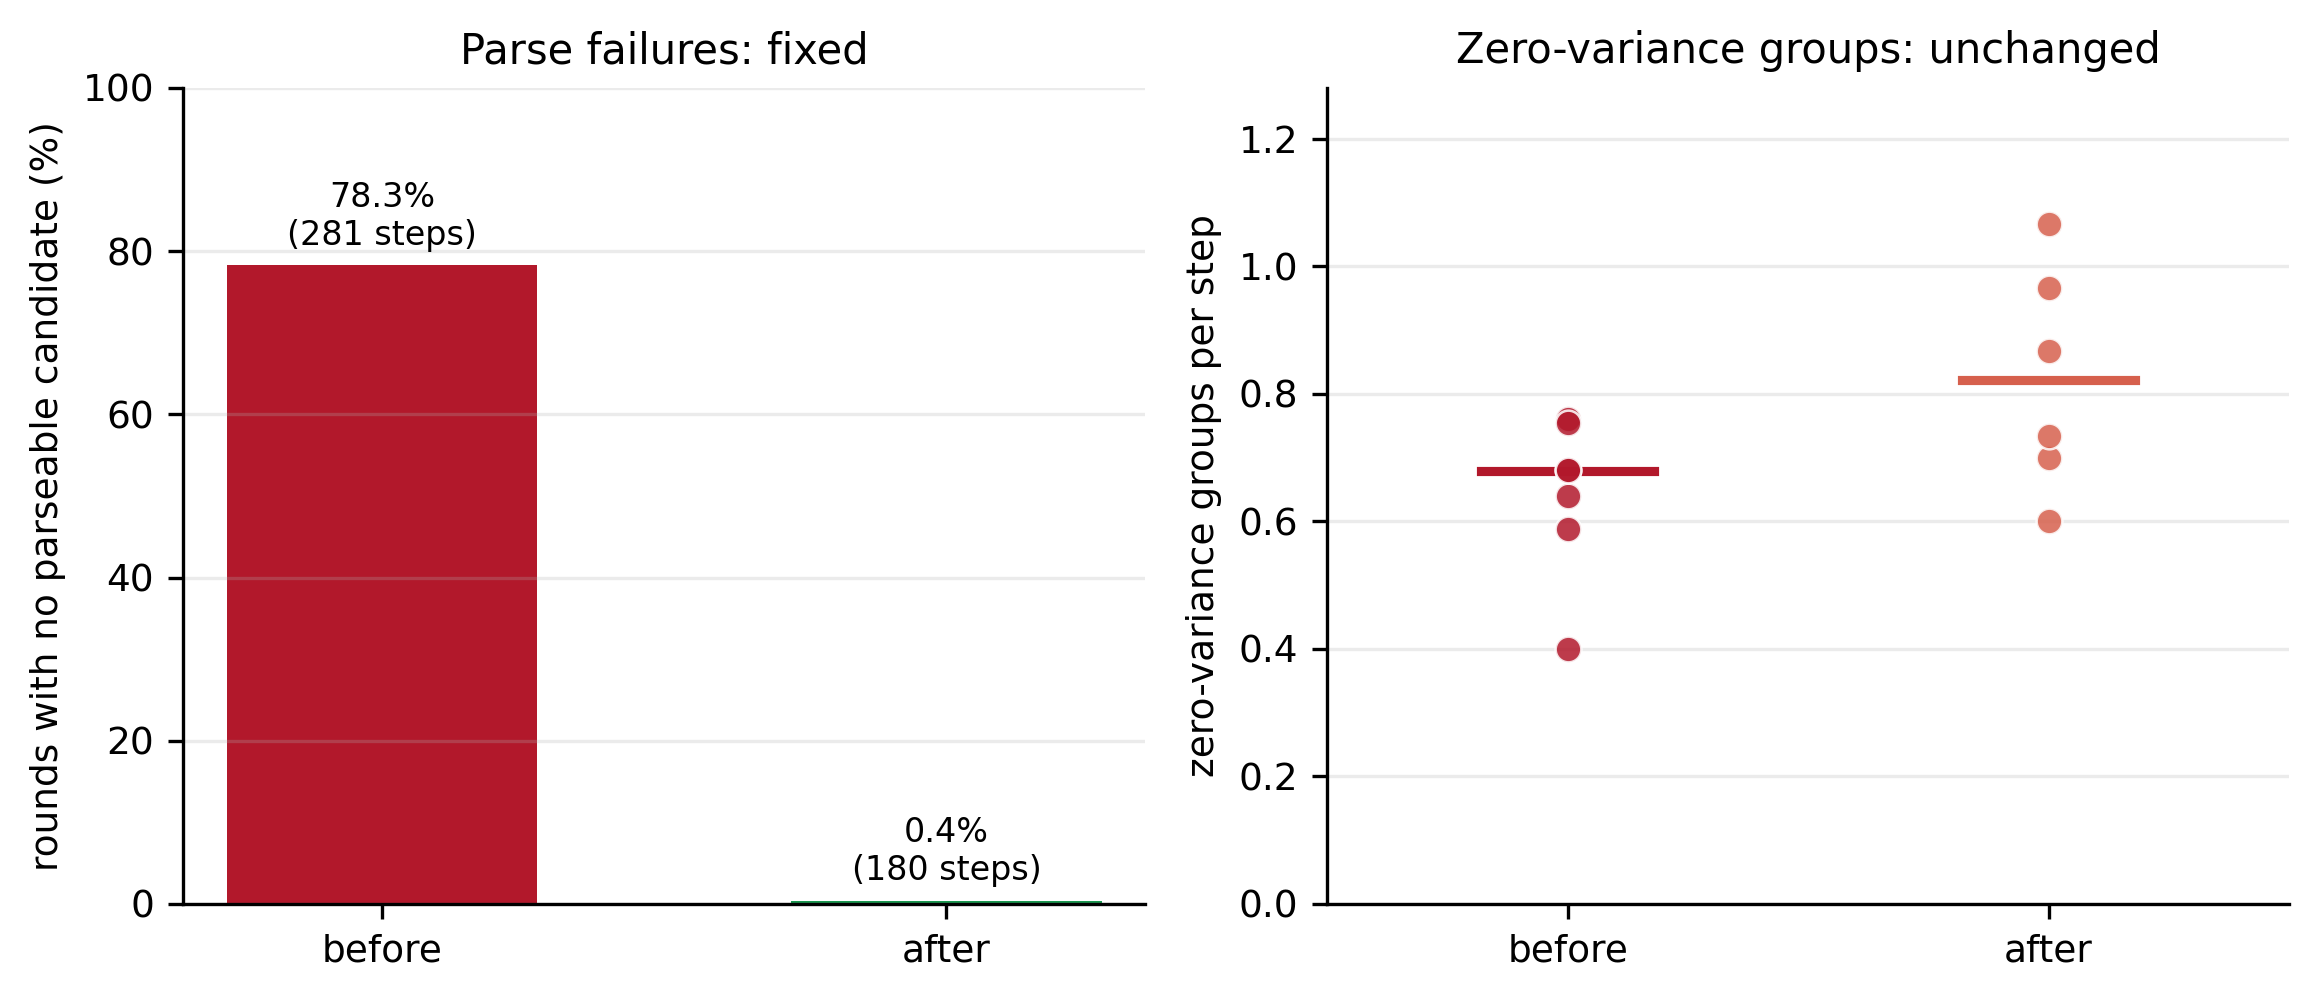

In [5]:
fix = load("chat_format_fix.json")
b, a = fix["before"], fix["after"]
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.4))

ax = axes[0]
bars = ax.bar(["before", "after"], [100*b["fail_rate"], 100*a["fail_rate"]],
              color=["#b2182b", "#1a9850"], width=.55)
for r, v, n in zip(bars, [100*b["fail_rate"], 100*a["fail_rate"]],
                   [b["steps"], a["steps"]]):
    ax.text(r.get_x()+r.get_width()/2, v+2.5, f"{v:.1f}%\n({n} steps)",
            ha="center", fontsize=8)
ax.set_ylim(0, 100); ax.set_ylabel("rounds with no parseable candidate (%)")
ax.set_title("Parse failures: fixed", fontsize=10); ax.grid(axis="x", alpha=0)

# per-run points, not just the pooled mean -- the pooled number moved the wrong
# way at small n and that is exactly what misled the first reading
ax = axes[1]
for i, (key, col) in enumerate([("before", "#b2182b"), ("after", "#d6604d")]):
    pts = fix[key]["per_run_zps"]
    ax.scatter([i]*len(pts), pts, s=38, color=col, alpha=.85, zorder=3,
               edgecolors="white", linewidths=.6)
    ax.plot([i-.18, i+.18], [fix[key]["zero_std_per_step"]]*2, lw=2.2,
            color=col, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["before", "after"])
ax.set_xlim(-.5, 1.5); ax.set_ylim(0, max(b["per_run_zps"]+a["per_run_zps"])*1.2)
ax.set_ylabel("zero-variance groups per step")
ax.set_title("Zero-variance groups: unchanged", fontsize=10)
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**读法（对上面写下的那三条）**：

| 说好的标准 | 实际 |
|---|---|
| 1. 解析失败率下降 | **78.3% → 0.4%**，基本清零 |
| 2. 每步零方差组下降 | **0.68 → 0.82**，没降，还略升了 |
| 3. advantage 出现 >1e-6 | 仍然极少 |

第 1 条很干净：1249 次解析失败变成 2 次。

**第 2 条没兑现，而这正是事先写好的那个分岔。** 说好的是「零方差不跟着降，
就说明解析失败不是它的原因，得去查 `n_samples_per_prompt` 和候选去重」。
现在解析失败率只有 0.4%，零方差却还是 0.82——**解析失败几乎不是原因**。

`n_samples_per_prompt` 现在是 2，一组只有两条轨迹，两条撞出同一个分子太容易；
候选去重也可能把不同轨迹并成同一个。`n=8` 那一组正在跑。

**中间报错过一次**：新代码只跑了 36 步时读到 0.39，看起来像降了 43%，
跑到 180 步就翻过来了。现在统计只算跑够 15 步的 run——只跑几步的 run，
这个数噪声大到没意义，0.00 和 1.00 都出现过。

## 还有一个独立的隐患

EHVI 随 GP 历史增长而衰减，到 300 个点时 8 个候选里已有 6 个是精确 0
（见 [05](05_gp_kernel_and_ehvi_decay.ipynb)）。一个 run 会积累到 500+ 点，
**历史越长，一组候选一起拿到 0 的概率越高，零方差会自然增多**。
这与格式问题相互独立，要分开处理。